<a href="https://colab.research.google.com/github/SantuMartire/Practicas-de-Machine-Learning/blob/main/Pre_Entrega_Proyecto_Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Proyecto Integrador de Machine Learning
## Predicción de Éxito de Videojuegos en Steam


**Alumno:** Santiago Mártire

---

# *Requerimientos:*



1.   Selección del dataset: indicar origen, breve descripción del problema que aborda y justificación de su elección.

1.   Análisis exploratorio inicial (EDA): distribución de variables, detección de valores faltantes, análisis de correlaciones, visualizaciones básicas.


1.   Limpieza de datos: tratamiento de valores nulos, duplicados, outliers (si corresponde).

2.   Transformaciones básicas: codificación de variables categóricas, escalado de variables numéricas, creación o eliminación de variables (si fuera necesario).



2.   Selección de variables relevantes para el modelo.



2.   División del dataset en conjuntos de entrenamiento y prueba.


---


## 1. 📦 Selección del Dataset

### Origen del Dataset

El dataset utilizado es el **Steam Store Games (Clean dataset)** publicado por **Nik Davis** en Kaggle:

🔗 https://www.kaggle.com/datasets/nikdavis/steam-store-games

Fue construido combinando datos de dos fuentes:
- **Steam API**: información oficial de cada juego (precio, plataformas, edad requerida, categorías, géneros, etc.).
- **SteamSpy API**: estadísticas de la comunidad como cantidad de dueños estimados, ratings y tiempos de juego.

El dataset contiene información de más de **27.000 videojuegos** publicados en la tienda de Steam hasta mayo de 2019.

---

### Descripción del Problema

Steam es la plataforma de distribución de videojuegos para PC más grande del mundo. Con miles de títulos nuevos lanzados cada año, tanto desarrolladores independientes como grandes estudios necesitan entender **qué factores influyen en que un juego sea bien recibido por los jugadores**.

> **¿Podemos predecir si un videojuego tendrá una buena recepción por parte de los usuarios en Steam, en base a sus características al momento del lanzamiento?**


### Justificación de la elección

Elegimos este dataset por varias razones. En primer lugar, la industria de los videojuegos mueve más de 180.000 millones de dólares anuales, por lo que predecir el éxito de un juego tiene valor real. En segundo lugar, el dataset combina variables numéricas (precio, ratings, playtime), categóricas (géneros, plataformas, desarrollador) y binarias, lo que nos va a permitir practicar todas las etapas del flujo de trabajo de Machine Learning. Por último, su tamaño es manejable en Google Colab sin necesidad de procesamiento especializado.

---

## 2. 🔍 Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) es el primer paso para entender la estructura y el contenido del dataset antes de cualquier procesamiento. Nos permite identificar:

- La forma general del dataset (dimensiones, tipos de datos)
- La distribución de las variables
- La presencia de valores nulos o anómalos
- Las correlaciones entre variables

---

### 2.1 Vista General del Dataset

In [6]:

# Librerías para el manejo de datos
import pandas as pd
import numpy as np

# Librerías para creación de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Librerías para pruebas estadísticas
from scipy import stats as st
import math as mt

# Libreria para importar directamente desde Kaggle
import kagglehub

# Extra: acceso a comandos del Sistema Operativo
import os

In [ ]:
# ==========================================================
# CARGAMOS EL DATASET
# ==========================================================

# Si el archivo ya está disponible en una ruta local, lo usamos directamente.
# En caso contrario, lo descargamos desde Kaggle.

ruta_local = "/content/games.csv"

if os.path.exists(ruta_local):
    ruta_csv = ruta_local
else:
    import kagglehub
    ruta_dataset = kagglehub.dataset_download("nikdavis/steam-store-games")
    ruta_csv = os.path.join(ruta_dataset, "steam.csv")

games = pd.read_csv(ruta_csv)

print("Dataset cargado correctamente.")
print("Dimensiones:", games.shape)

display(games.head())

Using Colab cache for faster access to the 'steam-store-games' dataset.
Dataset cargado correctamente.
Dimensiones: (27075, 18)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [7]:
# ==========================================================
# EXPLORACIÓN INICIAL DE LA ESTRUCTURA DEL DATASET
# ==========================================================
print("Dimensiones del dataset:", games.shape)

Dimensiones del dataset: (27075, 18)


In [8]:
print("\nInformación general (tpos de datos y valores no nulos):")
games.info()


Información general (tpos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-nu

In [9]:
print("Columnas del dataset:")
print(games.columns.tolist())

Columnas del dataset:
['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']


In [10]:
print("\nResumen estadístico de las variables numéricas:")
display(games.describe())


Resumen estadístico de las variables numéricas:


,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [ ]:
# ==========================================================
# REVISAMOS TIPOS DE DATOS Y VALORES FALTANTES
# ==========================================================

#games.info()

print("\nCantidad de valores nulos por columna:\n")
print(games.isnull().sum())
print("\n Porcentaje (%):")
print((games.isnull().sum() / len(games) * 100).round(2))



Cantidad de valores nulos por columna:

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

 Porcentaje (%):
appid               0.00
name                0.00
release_date        0.00
english             0.00
developer           0.00
publisher           0.05
platforms           0.00
required_age        0.00
categories          0.00
genres              0.00
steamspy_tags       0.00
achievements        0.00
positive_ratings    0.00
negative_ratings    0.00
average_playtime    0.00
median_playtime     0.00
owners              0.00
price               0.00
dtype: float64


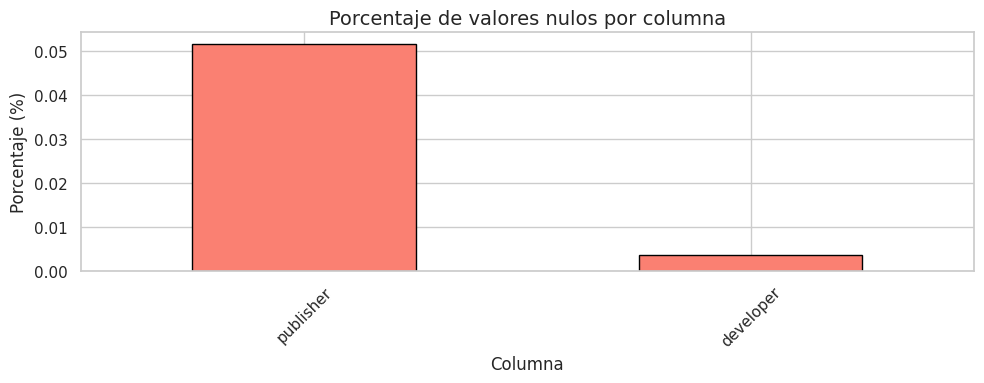

In [12]:
# ==========================================================
# VISUALIZACIÓN DE VALORES NULOS
# ==========================================================

missing_pct = (games.isnull().sum() / len(games) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))

if missing_pct.empty:
    ax.text(0.5, 0.5, 'Sin valores nulos en el dataset', ha='center', va='center',
            fontsize=14, transform=ax.transAxes)
    ax.axis('off')
else:
    missing_pct.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title('Porcentaje de valores nulos por columna')
    ax.set_xlabel('Columna')
    ax.set_ylabel('Porcentaje (%)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Creación de la variable objetivo

Antes de continuar con el análisis exploratorio, vamos a crear nuestra variable objetivo. Como mencionamos en la sección anterior, el objetivo es predecir si un juego va a tener una buena recepción por parte de los usuarios.

Para eso, usamos las columnas `positive_ratings` y `negative_ratings` para calcular el **porcentaje de aprobación** de cada juego. Un juego se considera **bien recibido** si supera el 70% de reviews positivas sobre el total.

También vamos a excluir los juegos con menos de 10 reviews en total, ya que no tienen suficiente representatividad estadística como para sacar conclusiones confiables.

In [16]:
# ==========================================================
# CREAMOS LA VARIABLE OBJETIVO: well_received
# ==========================================================

# Total de reviews por juego
games['total_ratings'] = games['positive_ratings'] + games['negative_ratings']

# Porcentaje de aprobación
games['approval_rate'] = games['positive_ratings'] / games['total_ratings']

# Filtramos juegos sin suficientes reviews
games_filtrado = games[games['total_ratings'] >= 10].copy()

print(f'Juegos totales en el dataset:        {len(games):,}')
print(f'Juegos con 10 o más reviews:         {len(games_filtrado):,}')
print(f'Juegos excluidos (menos de 10):      {len(games) - len(games_filtrado):,}')

# Creamos la variable objetivo con umbral del 70%
UMBRAL = 0.70
games_filtrado['well_received'] = (games_filtrado['approval_rate'] >= UMBRAL).astype(int)

print(f'\nDistribución de well_received (umbral >= {UMBRAL*100:.0f}%):')
print(games_filtrado['well_received'].value_counts())
print()
print('Balance de clases:')
print(games_filtrado['well_received'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Juegos totales en el dataset:        27,075
Juegos con 10 o más reviews:         20,511
Juegos excluidos (menos de 10):      6,564

Distribución de well_received (umbral >= 70%):
well_received
1    12799
0     7712
Name: count, dtype: int64

Balance de clases:
well_received
1    62.4%
0    37.6%
Name: proportion, dtype: object


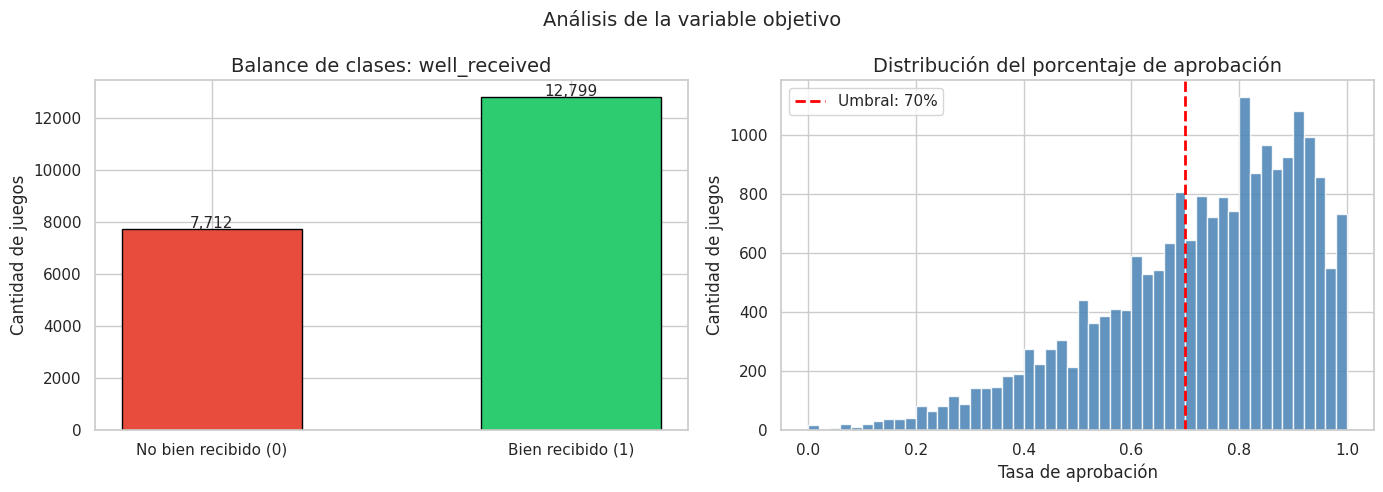

In [18]:
# ==========================================================
# VISUALIZACIÓN DEL BALANCE DE CLASES Y LA DISTRIBUCIÓN
# DE LA TASA DE APROBACIÓN
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balance de clases
counts = games_filtrado['well_received'].value_counts()
axes[0].bar(
    ['No bien recibido (0)', 'Bien recibido (1)'],
    [counts.get(0, 0), counts.get(1, 0)],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Balance de clases: well_received')
axes[0].set_ylabel('Cantidad de juegos')
for bar, val in zip(axes[0].patches, [counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,}', ha='center', fontsize=11
    )

# Distribución del porcentaje de aprobación
axes[1].hist(games_filtrado['approval_rate'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(UMBRAL, color='red', linestyle='--', linewidth=2, label=f'Umbral: {UMBRAL*100:.0f}%')
axes[1].set_title('Distribución del porcentaje de aprobación')
axes[1].set_xlabel('Tasa de aprobación')
axes[1].set_ylabel('Cantidad de juegos')
axes[1].legend()

plt.suptitle('Análisis de la variable objetivo', fontsize=14)
plt.tight_layout()
plt.show()

### Distribución de variables numéricas

Ahora vamos a analizar cómo se distribuyen las principales variables numéricas del dataset. En muchos casos, las distribuciones van a estar muy sesgadas hacia la derecha: hay pocos juegos con valores muy altos de precio, playtime o ratings, y muchos con valores bajos. Para poder visualizarlas mejor, vamos a aplicar una transformación logarítmica con `log1p` (que es equivalente a log(1+x) y funciona bien incluso cuando hay valores cero).

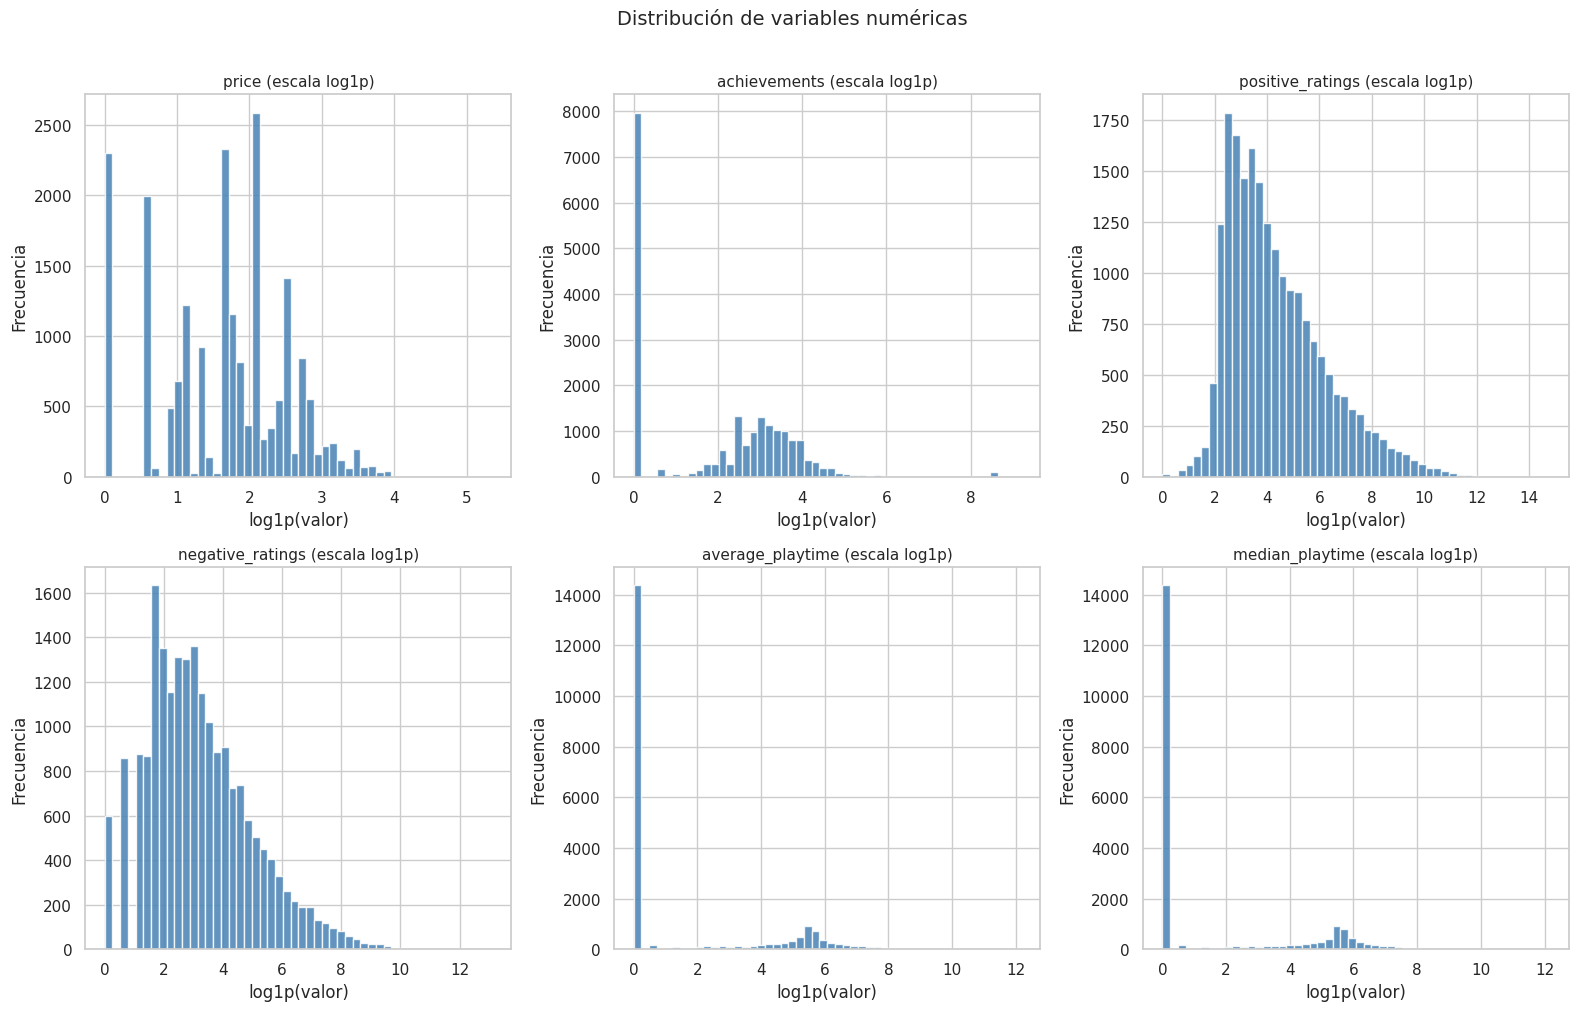

Se usa log1p para visualizar mejor las distribuciones sesgadas.
La mayoría de los juegos tienen pocos ratings y precios bajos, con excepciones muy altas.


In [19]:
# ==========================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS (ESCALA LOG)
# ==========================================================

num_cols = ['price', 'achievements', 'positive_ratings',
            'negative_ratings', 'average_playtime', 'median_playtime']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_log = np.log1p(games_filtrado[col].dropna())
    axes[i].hist(data_log, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} (escala log1p)', fontsize=11)
    axes[i].set_xlabel('log1p(valor)')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Se usa log1p para visualizar mejor las distribuciones sesgadas.')
print('La mayoría de los juegos tienen pocos ratings y precios bajos, con excepciones muy altas.')

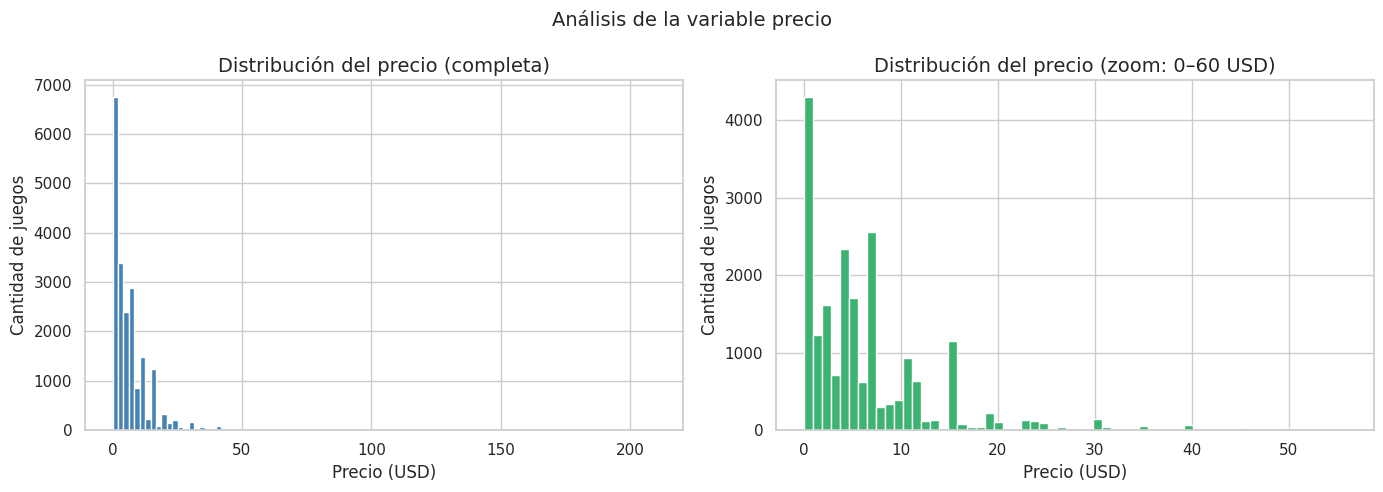

Juegos gratuitos (price = 0):  2,302 (11.2%)
Precio mediano:                $4.79
Precio máximo:                 $209.99


In [21]:
# ==========================================================
# ANÁLISIS DEL PRECIO: DISTRIBUCIÓN COMPLETA Y ZOOM
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución completa
axes[0].hist(games_filtrado['price'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del precio (completa)')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Cantidad de juegos')

# Zoom en la zona más densa
games_zoom = games_filtrado[games_filtrado['price'] <= 60]
axes[1].hist(games_zoom['price'], bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribución del precio (zoom: 0–60 USD)')
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Cantidad de juegos')

plt.suptitle('Análisis de la variable precio', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Juegos gratuitos (price = 0):  {(games_filtrado["price"] == 0).sum():,} ({(games_filtrado["price"] == 0).mean()*100:.1f}%)')
print(f'Precio mediano:                ${games_filtrado["price"].median():.2f}')
print(f'Precio máximo:                 ${games_filtrado["price"].max():.2f}')

### Análisis de variables categóricas

Varias de las columnas más interesantes del dataset son de tipo texto. En particular, las columnas `genres` y `platforms` contienen múltiples valores separados por punto y coma (por ejemplo, `"Action;Indie;RPG"` o `"windows;mac;linux"`).

Vamos a explorar cuáles son los géneros más frecuentes y cómo se distribuyen las plataformas, para entender mejor qué tipo de juegos forman parte del dataset.

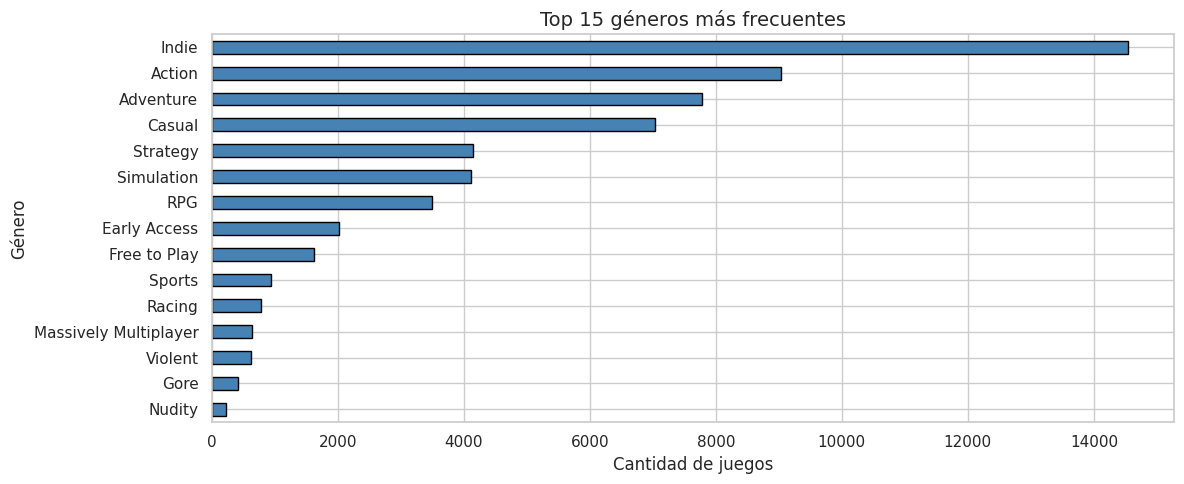

In [22]:
# ==========================================================
# GÉNEROS MÁS FRECUENTES EN EL DATASET
# ==========================================================

# La columna 'genres' tiene múltiples valores separados por ';'
# Usamos str.split y explode para contar cada género individualmente
generos = games_filtrado['genres'].dropna().str.split(';').explode().str.strip()
top_generos = generos.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_generos.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 15 géneros más frecuentes')
ax.set_xlabel('Cantidad de juegos')
ax.set_ylabel('Género')
plt.tight_layout()
plt.show()

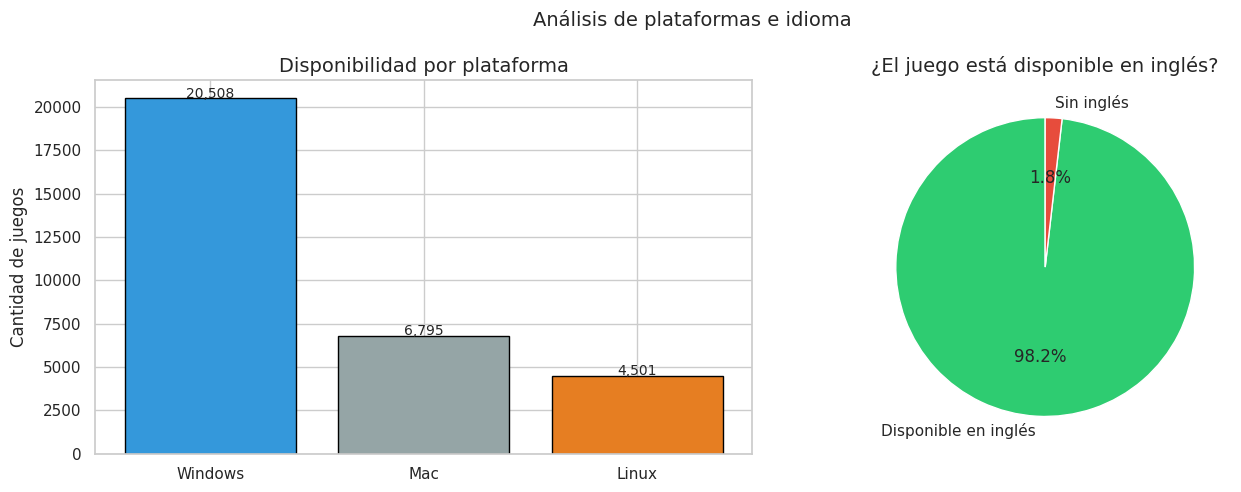

In [23]:
# ==========================================================
# DISTRIBUCIÓN DE PLATAFORMAS E IDIOMA
# ==========================================================

# Extraemos si cada juego está disponible en cada plataforma
games_filtrado['windows'] = games_filtrado['platforms'].str.contains('windows', na=False).astype(int)
games_filtrado['mac']     = games_filtrado['platforms'].str.contains('mac', na=False).astype(int)
games_filtrado['linux']   = games_filtrado['platforms'].str.contains('linux', na=False).astype(int)

platform_counts = {
    'Windows': games_filtrado['windows'].sum(),
    'Mac':     games_filtrado['mac'].sum(),
    'Linux':   games_filtrado['linux'].sum()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Disponibilidad por plataforma
axes[0].bar(
    platform_counts.keys(),
    platform_counts.values(),
    color=['#3498db', '#95a5a6', '#e67e22'],
    edgecolor='black'
)
axes[0].set_title('Disponibilidad por plataforma')
axes[0].set_ylabel('Cantidad de juegos')
for bar, val in zip(axes[0].patches, platform_counts.values()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{val:,}', ha='center', fontsize=10
    )

# Juegos disponibles en inglés
english_counts = games_filtrado['english'].value_counts()
axes[1].pie(
    english_counts,
    labels=['Disponible en inglés', 'Sin inglés'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[1].set_title('¿El juego está disponible en inglés?')

plt.suptitle('Análisis de plataformas e idioma', fontsize=14)
plt.tight_layout()
plt.show()

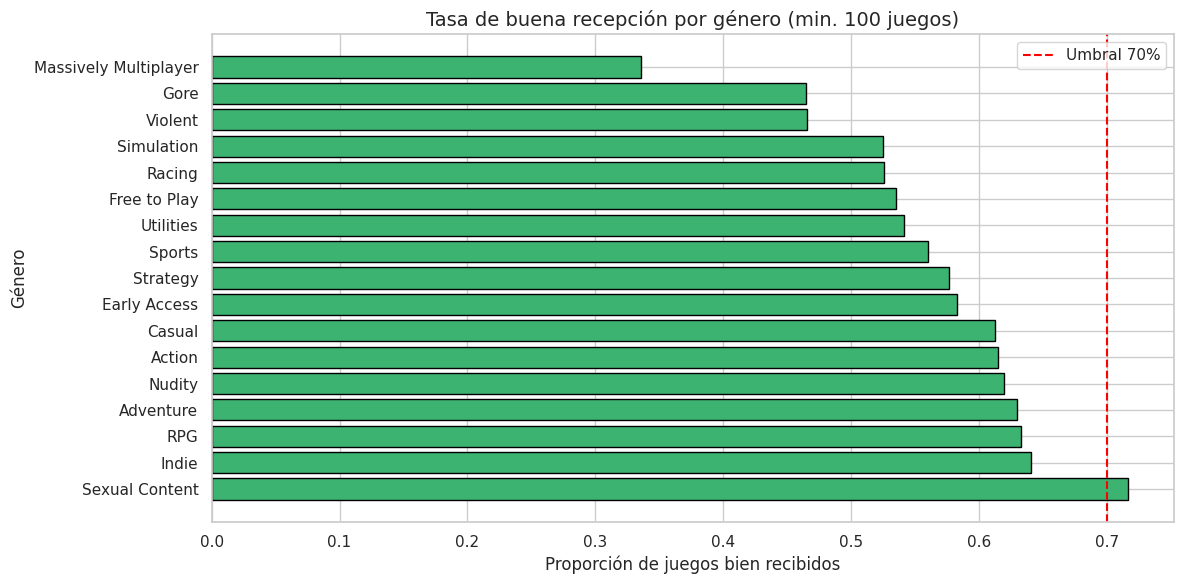

In [26]:
# ==========================================================
# TASA DE BUENA RECEPCIÓN POR GÉNERO
# ==========================================================

# ¿Hay géneros que tienden a ser mejor recibidos por los usuarios?
games_genres_exp = games_filtrado[['genres', 'well_received']].dropna(subset=['genres']).copy()
games_genres_exp['genres'] = games_genres_exp['genres'].str.split(';')
games_genres_exp = games_genres_exp.explode('genres')
games_genres_exp['genres'] = games_genres_exp['genres'].str.strip()

# Solo consideramos géneros con al menos 100 juegos para evitar conclusiones sobre muestras pequeñas
genre_reception = games_genres_exp.groupby('genres').agg(
    total=('well_received', 'count'),
    tasa_positiva=('well_received', 'mean')
).query('total >= 100').sort_values('tasa_positiva', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(genre_reception.index, genre_reception['tasa_positiva'],
        color='mediumseagreen', edgecolor='black')
ax.axvline(UMBRAL, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {UMBRAL*100:.0f}%')
ax.set_title('Tasa de buena recepción por género (min. 100 juegos)')
ax.set_xlabel('Proporción de juegos bien recibidos')
ax.set_ylabel('Género')
ax.legend()
plt.tight_layout()
plt.show()

### Análisis de correlaciones

Para cerrar el análisis exploratorio, vamos a revisar las correlaciones entre las variables numéricas. Esto nos permite identificar qué variables tienden a moverse juntas y cuáles tienen una relación más directa con la variable objetivo.

Vale aclarar que `approval_rate` va a aparecer con una correlación muy alta respecto a `well_received`, lo cual es esperable ya que es la variable a partir de la cual construimos el target. Por esa razón, vamos a **excluirla del modelo** en etapas posteriores.

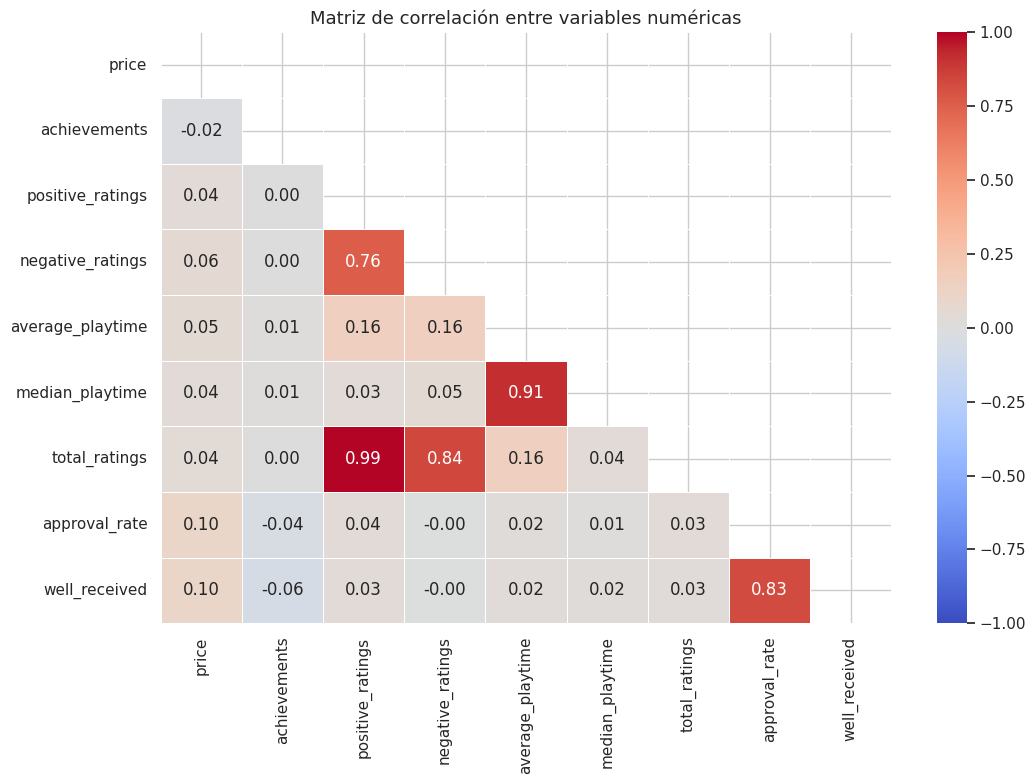

In [27]:
# ==========================================================
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ==========================================================

corr_cols = [
    'price', 'achievements', 'positive_ratings', 'negative_ratings',
    'average_playtime', 'median_playtime', 'total_ratings',
    'approval_rate', 'well_received'
]

corr_matrix = games_filtrado[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de correlación entre variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

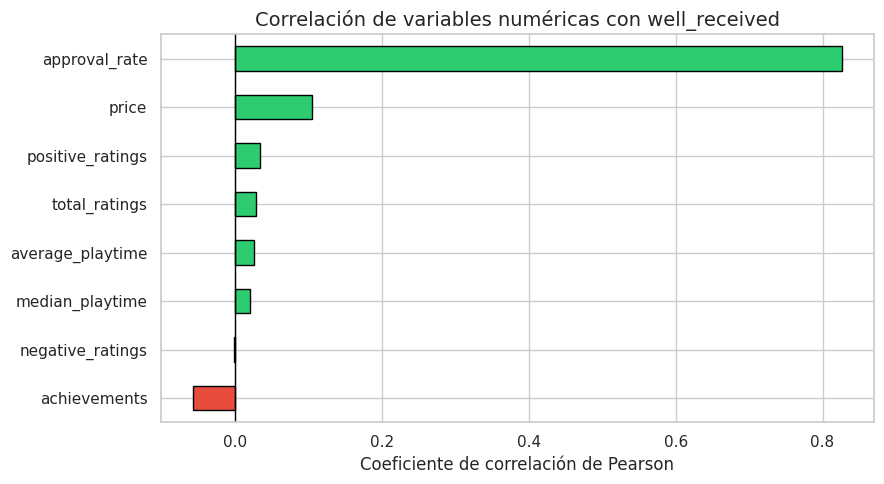

Variables con mayor correlación con el target (en valor absoluto):
approval_rate       0.825944
price               0.104279
achievements        0.057716
positive_ratings    0.033213
total_ratings       0.027698
Name: well_received, dtype: float64


In [29]:
# ==========================================================
# CORRELACIÓN DE CADA VARIABLE CON EL TARGET
# ==========================================================

corr_con_target = (
    games_filtrado[corr_cols]
    .corr()['well_received']
    .drop('well_received')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_con_target]
corr_con_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Correlación de variables numéricas con well_received')
ax.set_xlabel('Coeficiente de correlación de Pearson')
plt.tight_layout()
plt.show()

print('Variables con mayor correlación con el target (en valor absoluto):')
print(corr_con_target.abs().sort_values(ascending=False).head())

---

## 3. Limpieza de datos

Durante el análisis exploratorio pudimos identificar algunos problemas de calidad en el dataset que hay que resolver antes de avanzar hacia el modelado. En esta sección vamos a trabajar sobre tres aspectos:

1. **Valores nulos** en columnas de texto
2. **Registros duplicados**
3. **Outliers** en variables numéricas

Vamos a trabajar siempre sobre el DataFrame `games_filtrado`, que ya excluye los juegos con menos de 10 reviews.

### Tratamiento de valores nulos

Las columnas con valores faltantes que identificamos son principalmente de tipo texto. Vamos a aplicar un criterio diferenciado según la importancia de cada columna:

- **Columnas críticas** (`genres`, `developer`): si el valor es nulo, eliminamos la fila. Sin esta información, el registro no aporta valor al modelo.
- **Columnas de soporte** (`publisher`, `categories`, `steamspy_tags`): reemplazamos los nulos con el texto `'Unknown'` para no perder el registro completo.

In [31]:
# ==========================================================
# ESTADO DE VALORES NULOS ANTES DE LA LIMPIEZA
# ==========================================================

print('Valores nulos antes de la limpieza:')
nulos_antes = games_filtrado.isnull().sum()
print(nulos_antes[nulos_antes > 0])
print(f'\nTotal de filas: {len(games_filtrado):,}')

Valores nulos antes de la limpieza:
publisher    12
dtype: int64

Total de filas: 20,511


In [32]:
# ==========================================================
# TRATAMIENTO DIFERENCIADO DE VALORES NULOS
# ==========================================================

games_clean = games_filtrado.copy()

# Columnas críticas: eliminamos filas con nulos
columnas_criticas = ['genres', 'developer']
filas_antes = len(games_clean)
games_clean.dropna(subset=columnas_criticas, inplace=True)
print(f'Filas eliminadas por nulos en columnas críticas: {filas_antes - len(games_clean)}')

# Columnas de soporte: rellenamos con 'Unknown'
columnas_soporte = ['publisher', 'steamspy_tags', 'categories']
for col in columnas_soporte:
    if col in games_clean.columns:
        nulos_col = games_clean[col].isnull().sum()
        games_clean[col].fillna('Unknown', inplace=True)
        if nulos_col > 0:
            print(f'{col}: {nulos_col} nulos reemplazados con "Unknown"')

print(f'\nValores nulos después de la limpieza:')
nulos_despues = games_clean.isnull().sum()
if nulos_despues.sum() == 0:
    print('Sin valores nulos.')
else:
    print(nulos_despues[nulos_despues > 0])

print(f'\nTotal de filas: {len(games_clean):,}')

Filas eliminadas por nulos en columnas críticas: 0
publisher: 12 nulos reemplazados con "Unknown"

Valores nulos después de la limpieza:
Sin valores nulos.

Total de filas: 20,511


/tmp/ipykernel_4487/1701497080.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games_clean[col].fillna('Unknown', inplace=True)


### Detección y tratamiento de outliers

Analizamos los outliers en las variables numéricas principales. Para este dataset, muchos valores extremos son legítimos: los juegos más populares pueden tener millones de reviews o cientos de horas de playtime promedio.

Por esa razón, adoptamos una estrategia conservadora: solo intervenimos en los casos donde los outliers claramente no representan videojuegos, como es el caso de algunos títulos con precios extremadamente altos (software de productividad o herramientas publicadas en Steam con precios de cientos de dólares).

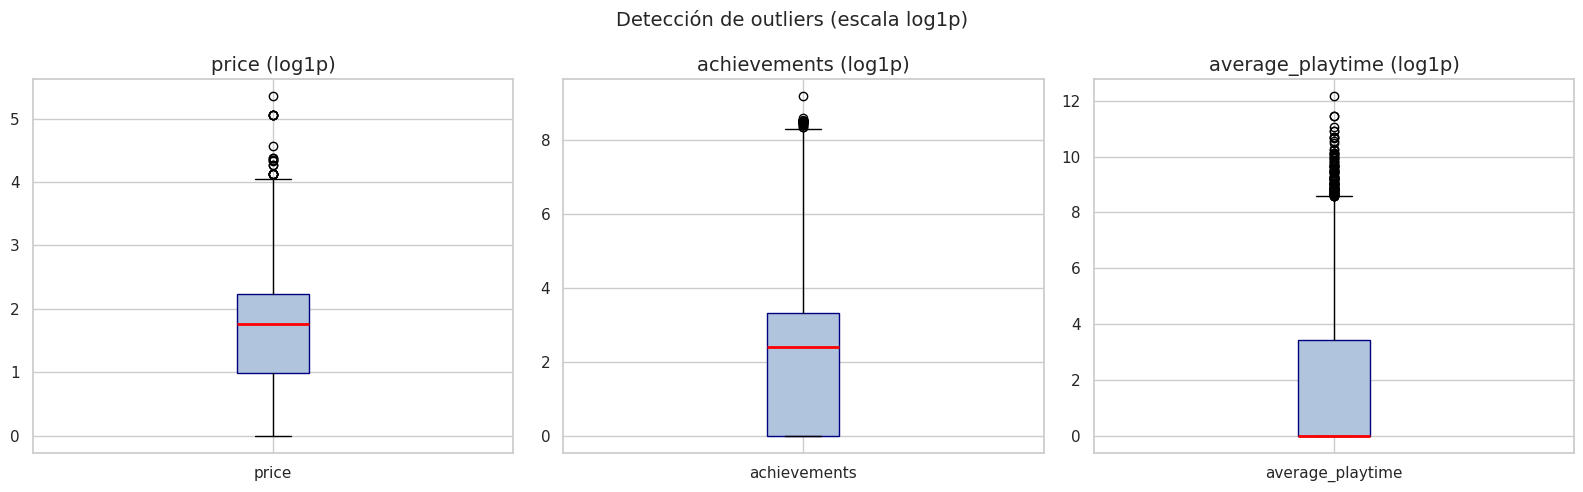

In [33]:
# ==========================================================
# VISUALIZACIÓN DE OUTLIERS CON BOXPLOTS
# ==========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_box = ['price', 'achievements', 'average_playtime']
for ax, col in zip(axes, vars_box):
    data = np.log1p(games_clean[col].dropna())
    ax.boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor='lightsteelblue', color='navy'),
        medianprops=dict(color='red', linewidth=2)
    )
    ax.set_title(f'{col} (log1p)')
    ax.set_xticklabels([col])

plt.suptitle('Detección de outliers (escala log1p)', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
# ==========================================================
# TRATAMIENTO DE OUTLIERS EN PRECIO
# ==========================================================

PRECIO_MAX = 200
outliers_precio = (games_clean['price'] > PRECIO_MAX).sum()

print(f'Registros con precio > ${PRECIO_MAX}: {outliers_precio}')

if outliers_precio > 0:
    print('\nEjemplos de juegos excluidos:')
    display(games_clean[games_clean['price'] > PRECIO_MAX][['name', 'price', 'genres']].head(10))

games_clean = games_clean[games_clean['price'] <= PRECIO_MAX].copy()
print(f'\nTotal de filas tras el filtro de precio: {len(games_clean):,}')

Registros con precio > $200: 1

Ejemplos de juegos excluidos:


,name,price,genres
10034,Houdini Indie,209.99,Animation & Modeling;Design & Illustration;Gam...



Total de filas tras el filtro de precio: 20,510


In [35]:
# ==========================================================
# FLAG PARA JUEGOS SIN DATOS DE PLAYTIME
# ==========================================================

# Muchos juegos tienen average_playtime = 0 porque SteamSpy no tiene datos
# En lugar de eliminarlos, creamos una variable binaria que identifique este caso
games_clean['sin_datos_playtime'] = (games_clean['average_playtime'] == 0).astype(int)

print(f'Juegos sin datos de playtime (average_playtime = 0): {games_clean["sin_datos_playtime"].sum():,}')
print('Se creó la variable binaria sin_datos_playtime para identificarlos.')

Juegos sin datos de playtime (average_playtime = 0): 14,377
Se creó la variable binaria sin_datos_playtime para identificarlos.


### Resumen del proceso de limpieza

Al finalizar las tres etapas de limpieza, verificamos el estado general del dataset.

In [37]:
# ==========================================================
# RESUMEN FINAL DEL DATASET LIMPIO
# ==========================================================

print('=' * 55)
print('        RESUMEN DEL DATASET TRAS LA LIMPIEZA')
print('=' * 55)
print(f'  Filas originales:                {len(games):>8,}')
print(f'  Tras filtrar (< 10 reviews):     {len(games_filtrado):>8,}')
print(f'  Dataset limpio final:            {len(games_clean):>8,}')
print(f'  Columnas:                        {games_clean.shape[1]:>8}')
print(f'  Valores nulos restantes:         {games_clean.isnull().sum().sum():>8}')
print(f'  Duplicados:                      {games_clean.duplicated().sum():>8}')
print('─' * 55)
vc = games_clean['well_received'].value_counts()
print(f'  Distribución del target:')
print(f'    Bien recibidos (1):            {vc.get(1, 0):>8,} ({vc.get(1,0)/len(games_clean)*100:.1f}%)')
print(f'    No bien recibidos (0):         {vc.get(0, 0):>8,} ({vc.get(0,0)/len(games_clean)*100:.1f}%)')
print('=' * 55)

        RESUMEN DEL DATASET TRAS LA LIMPIEZA
  Filas originales:                  27,075
  Tras filtrar (< 10 reviews):       20,511
  Dataset limpio final:              20,510
  Columnas:                              25
  Valores nulos restantes:                0
  Duplicados:                             0
───────────────────────────────────────────────────────
  Distribución del target:
    Bien recibidos (1):              12,798 (62.4%)
    No bien recibidos (0):            7,712 (37.6%)


In [39]:
# ==========================================================
# GUARDAMOS EL DATASET LIMPIO PARA LA PRÓXIMA ETAPA
# ==========================================================

games_clean.to_csv('steam_clean.csv', index=False)
print('Dataset limpio guardado como steam_clean.csv')

Dataset limpio guardado como steam_clean.csv


---

## Conclusiones de la etapa

### Lo que encontramos en el EDA

- El dataset contiene más de 27.000 juegos, de los cuales trabajamos con aquellos que tienen al menos 10 reviews para garantizar representatividad estadística.
- La distribución del precio está fuertemente sesgada: la mayoría de los juegos son gratuitos o cuestan menos de $20.
- Las variables de ratings y playtime también tienen distribuciones muy asimétricas, lo que sugiere que vamos a necesitar aplicar transformaciones logarítmicas.
- Los géneros más frecuentes son Indie, Action y Adventure. Algunos géneros más especializados tienden a tener mejor recepción.
- La variable `approval_rate` tiene una correlación muy alta con el target porque fue usada para construirlo; deberá excluirse del conjunto de features.

### Decisiones de limpieza

| Problema | Decisión |
|---|---|
| Juegos con menos de 10 reviews | Excluidos del análisis |
| Nulos en `developer` y `genres` | Filas eliminadas |
| Nulos en `publisher`, `categories`, `steamspy_tags` | Reemplazados con `'Unknown'` |
| Juegos con precio > $200 | Eliminados (no son videojuegos convencionales) |
| `average_playtime = 0` | Conservados + flag binario `sin_datos_playtime` |

### Próximos pasos

En la siguiente etapa vamos a trabajar sobre las **transformaciones** necesarias para preparar los datos para el modelado: codificación de variables categóricas, escalado de variables numéricas, selección de features y división en conjuntos de entrenamiento y prueba.